# Power System Simulation Package

**Final Presentation – Power System Computation and Simulation**

Team: *Power_Flow*  
Members: *Christina Vaintirli, Christo Christozov, Emir Terzier, Mehmet Kizildenizli, Yigit Delmen*

---

## Presentation Structure

1. Project overview  
2. Assignment 1 & 2  
3. EV analysis  
4. N-1 analysis  
5. Tap optimization  
6. Collaboration and conclusions


# 1. Project Overview

**Presenter:** *Yigit*

## Goal of the project

A python package for distribution-grid analysis. You give it a grid and load profiles, and it answers planning questions about voltages, losses, EVs, tap settings, and contingencies. 

The project has three aims:

- Build a Python package for power system analysis
- Apply real software engineering practices: Git, testing, documentation, packaging
- Demonstrate functionality on realistic grids.
  
## Package overview

The package is organized in **three layers**, one per assignment, each based on the one before it: 
- **Graph Layer** (Assignment 1), grid topology: connectivity, cycles. which houses sit on which feeder.
- **Power-Flow Layer** (Assignment 2), time-series power flow calculation and result aggregation into two tables: per timestep voltages and per-line loading/losses.
- **Analytics Layer** (Assignment 3), EV penetration, tap optimization, and N-1 contingency: Uses the previous two layers to reshape the input and read the tables back.

Everything is driven by one dataclass. `PowerSystemCase`, that bundles the grid, the load profiles, the EV pool and the feeder IDs. 
For every feature the following sequence repeats: **Build a case → validate → call one analysis → read two tables**

In [40]:
# Core libaries used throughout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The package's public API — one case object, then one call per analysis
from power_system_simulation import (
    PowerSystemCase, 
    validate_case, 
    PowerFlowProcessor, 
    run_ev_penetration_analysis, 
    optimize_tap_position, 
    run_n_minus_one_analysis, 
)
from power_system_simulation.grid_graph import build_graph_processor

In [10]:
# Public API, grouped by layer 
print("Layer 1 - Graph:        build_graph_processor, GraphProcessor")
print("Layer 2 - Power flow:   PowerFlowProcessor (run_time_series, get_voltage_summary, get_line_summary)")
print("Layer 3 - Analytics:    run_ev_penetration_analysis, optimize_tap_position, run_n_minus_one_analysis")
print("Shared:                 PowerSystemCase, validate_case")


Layer 1 - Graph:        build_graph_processor, GraphProcessor
Layer 2 - Power flow:   PowerFlowProcessor (run_time_series, get_voltage_summary, get_line_summary)
Layer 3 - Analytics:    run_ev_penetration_analysis, optimize_tap_position, run_n_minus_one_analysis
Shared:                 PowerSystemCase, validate_case


# 2. Assignment 1 & 2

**Presenter:** *Christina*

These are the two foundation layers, everything in Assignment 3 is built directly on top of them. 

## Assignment 1: Graph processing

Forgetting about electricity, grids is just some dots connected by lines, otherwise known as a *graph*. This layer answers topology questions about the structure: 

- **Downstream vertex detection:** Given a wire, which houses sit below it, further away from the source? This is used to find which houses belong to which feeder.
  
- **Alternative edge detection:** Grids are built as loops but often run as a tree with some branches/wires being switched off. If a wire fails, which switched-off wires can be turned on to reconnect everyone?

- **Handling radial and meshed networks:** #maybe remove

### Design notes

**Adjacency list for storage.** The grid is stored as an adjacency list —
each vertex keeps a short list of its `(neighbour, edge_id)` pairs. Power grids
are *sparse* (a tree of V vertices has only V−1 edges, so each vertex touches
just a few others), so a list stores only the connections that actually exist
and lets us read a vertex's neighbours directly. Processing a vertex costs
O(degree(v)), and a full traversal is O(V + E) — which, since E = V − 1 for our
tree, is linear in the size of the grid. A dense V×V adjacency matrix would be
mostly empty and waste both memory and lookup time.

**One BFS at construction, reused everywhere.** We run a single
breadth-first search from the source when the object is built, and it does two
jobs at once:
- **Connectivity check** — a vertex ends up in `distance_from_source` *iff* it
  is reachable from the source. If the dictionary doesn't cover every vertex,
  the grid is disconnected (`GraphNotFullyConnectedError`).
- **Distance precomputation** — because BFS expands outward in rings, the ring a
  vertex lands in *is* its hop-distance from the source, which we store in
  `distance_from_source`.

That stored distance is what makes `find_downstream_vertices` trivial: the
downstream end of any edge is simply the endpoint with the **larger** distance —
an instant comparison instead of re-deriving direction each call. (BFS over DFS
specifically because BFS yields this distance for free; DFS does not.)

**Disabled edges are retained.** Open (disabled) lines stay in `edge_map`, so
`find_alternative_edges` can consider them as reconnection candidates without
rebuilding the graph.

**Cycle check by counting.** A valid spanning tree has exactly V−1 enabled
edges, so after the connectivity check we simply compare the enabled-edge count
to V−1 (`GraphCycleError` otherwise) — no extra traversal needed.

*The theme: do the expensive work once at construction (build the list, run one
BFS), then every later query just reads the precomputed result. This matters
because Assignment 3 calls these graph functions repeatedly.*

## Assignment 2: Power flow result processing

This is the physics engine. Given the grid and how much power each house draws
**at every timestep**, it runs a time-series power flow and aggregates the raw
output into two summary tables:

- **Node/voltage table** — per timestep, the highest and lowest voltage in the
  grid and which node they occurred at. (Are we in the safe voltage band?)
- **Line table** — per wire: its peak loading and when, plus total **energy loss**
  over the period, computed by integrating power loss over time (trapezoidal rule)
  and converting to kWh.

*These two tables are the output that every Assignment 3 analysis reads back.*


In [29]:
import json
from pathlib import Path
from power_grid_model import ComponentType
from power_grid_model.utils import json_deserialize_from_file

DATA_DIR = Path("../../Downloads/Input_Data_for_Demo")    # path to test file
#DATA_DIR = Path("../../Downloads/input")    # path to test file

input_data = json_deserialize_from_file(DATA_DIR / "input_network_data.json")
active_power_profile   = pd.read_parquet(DATA_DIR / "active_power_profile.parquet")
reactive_power_profile = pd.read_parquet(DATA_DIR / "reactive_power_profile.parquet")
ev_pool                = pd.read_parquet(DATA_DIR / "ev_active_power_profile.parquet")
meta_data = json.loads((DATA_DIR / "meta_data.json").read_text())
lv_feeder_ids = meta_data["lv_feeders"]   # 

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=lv_feeder_ids,
    ev_active_power_profiles=ev_pool,
)

print(f"Loaded: {active_power_profile.shape[1]} houses, "
      f"{len(input_data[ComponentType.line]['id'])} lines, "
      f"{active_power_profile.shape[0]} timesteps")
print(f"Feeders: {lv_feeder_ids}")

Loaded: 400 houses, 807 lines, 35040 timesteps
Feeders: [1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904]


In [30]:
# Assignment 1 Demo

from power_system_simulation.grid_graph import build_graph_processor

graph = build_graph_processor(case.input_data)

# Downstream detection: which nodes sit below each feeder line
for feeder_id in case.lv_feeder_ids[:3]:          # only print the first few feeders, to keep output short
    downstream = graph.find_downstream_vertices(feeder_id)
    print(f"Feeder line {feeder_id}: {len(downstream)} downstream nodes")

# Alternative-edge detection: if a feeder is lost, which open lines can restore the grid?
example = case.lv_feeder_ids[0]
print(f"\nIf line {example} fails, lines that could reconnect the grid: "
      f"{graph.find_alternative_edges(example)}")

Feeder line 1204: 100 downstream nodes
Feeder line 1304: 100 downstream nodes
Feeder line 1404: 100 downstream nodes

If line 1204 fails, lines that could reconnect the grid: [2004]


Voltage summary (first rows):


,Max_Voltage,Max_Voltage_Node,Min_Voltage,Min_Voltage_Node
Timestamp,,,,
2025-01-01 00:00:00,1.074658,1,1.049898,0
2025-01-01 00:15:00,1.074532,1,1.049891,0
2025-01-01 00:30:00,1.074927,1,1.049916,0
2025-01-01 00:45:00,1.074601,1,1.049894,0
2025-01-01 01:00:00,1.074482,1,1.049885,0



Line summary (first rows):


,Total_Loss,Max_Loading,Max_Loading_Timestamp,Min_Loading,Min_Loading_Timestamp
Line_ID,,,,,
1204,53.619019,0.058248,2025-11-07 09:45:00,4.447163e-03,2025-10-08 12:45:00
1205,0.184181,0.005681,2025-04-07 10:30:00,4.082249e-07,2025-03-04 17:15:00
1206,54.899474,0.054426,2025-11-05 23:15:00,3.731235e-03,2025-10-08 12:45:00
1207,0.224576,0.004753,2025-05-29 02:30:00,4.118517e-07,2025-12-29 15:30:00
1208,50.536788,0.056481,2025-11-07 09:45:00,3.791173e-03,2025-10-08 12:45:00


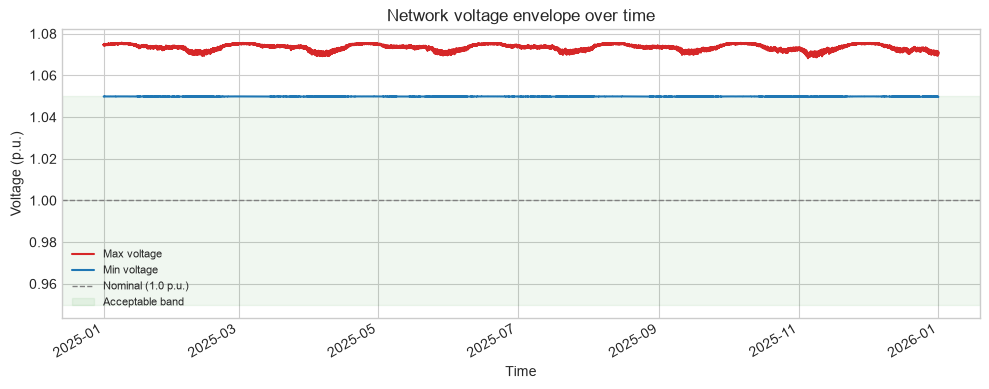

In [31]:
# Assignment 2 Demo
processor = PowerFlowProcessor(
    case.input_data, case.active_power_profile, case.reactive_power_profile
)
processor.run_time_series()

voltage_summary = processor.get_voltage_summary()
line_summary = processor.get_line_summary()

print("Voltage summary (first rows):")
display(voltage_summary.head())
print("\nLine summary (first rows):")
display(line_summary.head())

# Voltage envelope figure
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(voltage_summary.index, voltage_summary["Max_Voltage"], color="#d62728", label="Max voltage")
ax.plot(voltage_summary.index, voltage_summary["Min_Voltage"], color="#1f77b4", label="Min voltage")
ax.axhline(1.0, ls="--", color="grey", lw=1, label="Nominal (1.0 p.u.)")
ax.axhspan(0.95, 1.05, color="green", alpha=0.06, label="Acceptable band")
ax.set_title("Network voltage envelope over time")
ax.set_xlabel("Time"); ax.set_ylabel("Voltage (p.u.)")
ax.legend(loc="lower left", fontsize=8)
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

In [33]:
# KPIs
import time

def timed(label, fn):
    t0 = time.perf_counter(); fn(); return (time.perf_counter() - t0) * 1000

n_nodes  = len(case.input_data[ComponentType.node]["id"])
n_lines  = len(case.input_data[ComponentType.line]["id"])
n_houses = case.active_power_profile.shape[1]
n_steps  = case.active_power_profile.shape[0]

print("=== Grid KPIs ===")
print(f"Nodes: {n_nodes}   Lines: {n_lines}   Households: {n_houses}   Timesteps: {n_steps}")
print(f"Total load-points solved: {n_houses * n_steps:,}\n")

print("=== Runtime breakdown (single time-series run) ===")
t_build = timed("Build model + batch update", lambda: PowerFlowProcessor(
    case.input_data, case.active_power_profile, case.reactive_power_profile))
p = PowerFlowProcessor(case.input_data, case.active_power_profile, case.reactive_power_profile)
t_solve = timed("PGM solve (the physics)",   lambda: p.run_time_series())
t_volt  = timed("Voltage aggregation",        lambda: p.get_voltage_summary())
t_line  = timed("Line aggregation",           lambda: p.get_line_summary())
total = t_build + t_solve + t_volt + t_line

for label, t in [("Build", t_build), ("Solve", t_solve), ("Voltage agg", t_volt), ("Line agg", t_line)]:
    print(f"  {label:<22}{t:8.1f} ms   ({t/total*100:4.1f}%)")
print(f"  {'TOTAL':<22}{total:8.1f} ms")
print(f"\n  -> The solver is the cost; our Python aggregation is ~{(t_volt+t_line)/total*100:.1f}% of total.")

=== Grid KPIs ===
Nodes: 802   Lines: 807   Households: 400   Timesteps: 35040
Total load-points solved: 14,016,000

=== Runtime breakdown (single time-series run) ===
  Build                    222.7 ms   ( 0.6%)
  Solve                  35555.7 ms   (96.8%)
  Voltage agg              121.5 ms   ( 0.3%)
  Line agg                 813.9 ms   ( 2.2%)
  TOTAL                  36713.7 ms

  -> The solver is the cost; our Python aggregation is ~2.5% of total.


# 3. EV Analysis

**Presenter:** *[Name]*

## Scenario

Explain the EV integration scenario:

- Base case
- EV loading case
- Main assumptions

## Key results

Show the impact on:

- Line/transformer loading
- Voltage levels
- Bottlenecks


In [43]:
# EV analysis demo
import json
import pandas as pd
from power_grid_model.utils import json_deserialize
from power_system_simulation.case import PowerSystemCase

DATA_DIR = Path("../../Downloads/Input_Data_for_Demo")

with open(f"{DATA_DIR}/input_network_data.json") as f:
    input_data = json_deserialize(f.read())

active_power_profile = pd.read_parquet(f"{DATA_DIR}/active_power_profile.parquet")
reactive_power_profile = pd.read_parquet(f"{DATA_DIR}/reactive_power_profile.parquet")
ev_active_power_profiles = pd.read_parquet(f"{DATA_DIR}/ev_active_power_profile.parquet")

with open(f"{DATA_DIR}/meta_data.json") as f:
    meta = json.load(f)
lv_feeder_ids = meta["lv_feeders"]

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=lv_feeder_ids,
    ev_active_power_profiles=ev_active_power_profiles,
)
print("Case loaded successfully.")


Case loaded successfully.


In [44]:
# EV analysis 
from power_system_simulation.ev_analysis import run_ev_penetration_analysis

voltage_summary, line_summary = run_ev_penetration_analysis(
    case,
    penetration_level=0.3,
    random_seed=42,
)

print("Voltage Summary:")
display(voltage_summary)

print("\nLine Summary:")
display(line_summary)


Voltage Summary:


,Max_Voltage,Max_Voltage_Node,Min_Voltage,Min_Voltage_Node
Timestamp,,,,
2025-01-01 00:00:00,1.074658,1,1.049898,0
2025-01-01 00:15:00,1.074532,1,1.049891,0
2025-01-01 00:30:00,1.074927,1,1.049916,0
2025-01-01 00:45:00,1.074601,1,1.049894,0
2025-01-01 01:00:00,1.074482,1,1.049885,0
...,...,...,...,...
2025-12-31 22:45:00,1.070124,1,1.049706,0
2025-12-31 23:00:00,1.070505,1,1.049730,0
2025-12-31 23:15:00,1.070528,1,1.049718,0



Line Summary:


,Total_Loss,Max_Loading,Max_Loading_Timestamp,Min_Loading,Min_Loading_Timestamp
Line_ID,,,,,
1204,58.971142,6.453956e-02,2025-05-30 16:15:00,4.447163e-03,2025-10-08 12:45:00
1205,0.184227,5.680893e-03,2025-04-07 10:30:00,4.080074e-07,2025-03-04 17:15:00
1206,60.509425,6.025848e-02,2025-05-30 16:15:00,3.731235e-03,2025-10-08 12:45:00
1207,0.224636,4.752569e-03,2025-05-29 02:30:00,4.117966e-07,2025-12-29 15:30:00
1208,55.825296,6.254118e-02,2025-05-30 16:15:00,3.791173e-03,2025-10-08 12:45:00
...,...,...,...,...,...
2006,0.008010,2.444596e-07,2025-01-06 12:00:00,2.390435e-07,2025-05-29 22:30:00
2007,0.007911,2.444948e-07,2025-10-08 17:45:00,2.393847e-07,2025-12-26 20:45:00
2008,0.009350,2.444761e-07,2025-04-27 15:00:00,2.395050e-07,2025-12-31 15:15:00


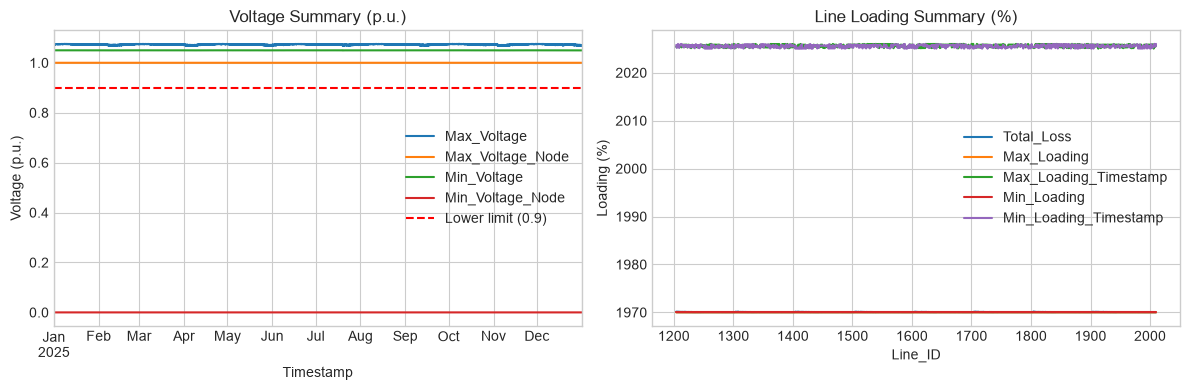

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

voltage_summary.plot(ax=axes[0], title="Voltage Summary (p.u.)")
axes[0].set_ylabel("Voltage (p.u.)")
axes[0].axhline(y=0.9, color='r', linestyle='--', label='Lower limit (0.9)')
axes[0].legend()

line_summary.plot(ax=axes[1], title="Line Loading Summary (%)")
axes[1].set_ylabel("Loading (%)")

plt.tight_layout()
plt.show()

# 4. N-1 Analysis

**Presenter:** *[Name]*

## Goal

Explain the purpose of N-1 analysis:

- Remove one network component at a time
- Re-run power flow
- Identify critical contingencies

## Key results

Show:

- Most critical outage
- Resulting overloads or voltage violations
- Interpretation of network robustness


In [ ]:
# N-1 analysis demo placeholder

# - Select contingency
# - Run N-1 analysis
# - Display affected components


In [ ]:
# N-1 analysis visualization placeholder

# - Plot or tabulate worst contingencies


# 5. Tap Optimization

**Presenter:** *Christo*

## Problem

Transformer tap positions influence voltage levels in the network.

The goal of this section is to demonstrate how the package can:

- Detect voltage problems
- Evaluate tap positions
- Select a tap setting that improves voltage quality

## Method

1. Run the initial power flow
2. Check voltage limits
3. Sweep or optimize tap positions
4. Re-run power flow with the selected tap setting
5. Compare before and after results


In [ ]:
# Tap optimization setup

# - Load grid/input data
# - Define voltage limits
# - Define candidate tap positions
# - Run base power flow


In [ ]:
# Tap optimization execution

# - Run tap optimization function
# - Store optimal tap result
# - Re-run power flow using optimized tap setting


In [ ]:
# Tap optimization result summary

# - Create before/after table:
#   - selected tap position
#   - minimum voltage
#   - maximum voltage
#   - number of voltage violations
#   - objective value, if applicable

# Example placeholder:
tap_summary = pd.DataFrame(
    {
        "Case": ["Before optimization", "After optimization"],
        "Tap position": ["-", "TODO"],
        "Minimum voltage [p.u.]": ["TODO", "TODO"],
        "Maximum voltage [p.u.]": ["TODO", "TODO"],
        "Voltage violations": ["TODO", "TODO"],
    }
)

tap_summary


In [ ]:
# Tap optimization visualization

# - Plot voltage profile before and after optimization
# - Maybe: plot objective value per tap position


## Tap Optimization Conclusion

Initial problem -> Tap Setting -> Optimization -> Voltage profile improvement


# 6. Collaboration and Conclusions

## Collaboration

We worked on GitHub with a feature-branch workflow where each person branched off for their piece. When ready to merge one would open a pull request, and after two other teammates would review the PR, the branch would be ready to be merged to main. That kept main safe and always working. It simultaneously meant at least two people saw every change.

## AI usage

We used AI tools as a learning and productivity aid, to help debug, to draft tests and documentation, and to prepare this presentation. Critically, everything it produced was reviewed and verified by us, we validated the actual results against the course's expected output, and nothing went in that we didn't understand and check ourselves.

## Final conclusion

To summarize, we built a working, tested Python package. It implements graph topology analysis and time-series power flow, and applies them to real planning questions. We treated this assignment as a real software project: using feature branches, reviews, CI, 99% test coverage, and output verified exactly against the course's reference. We worked and produced output while always keeping in mind efficiency: keeping memory usage and running time low while also creating a simple and intuitive working python package. 

# Backup / Extra Material

**Appendix:** 
- Validation - Assignment 2 expected output
- Tests - 99% coverage


In [38]:
# Validation - Assignment 2 results (as given on shared drive)
import pandas as pd
from pathlib import Path
from power_grid_model.utils import json_deserialize_from_file
from power_system_simulation import PowerFlowProcessor

# Folder holding the validation grid as given for Assignment 2 & its expected-output files.
VAL_DIR_input = Path("../../Downloads/input")    
VAL_DIR_output = Path("../../Downloads/output")

# Load the inputs
input_data        = json_deserialize_from_file(VAL_DIR_input / "input_network_data.json")
active_profile    = pd.read_parquet(VAL_DIR_input / "active_power_profile.parquet")
reactive_profile  = pd.read_parquet(VAL_DIR_input / "reactive_power_profile.parquet")

# Load the expected outputs
expected_voltage  = pd.read_parquet(VAL_DIR_output / "output_table_row_per_timestamp.parquet")
expected_line     = pd.read_parquet(VAL_DIR_output / "output_table_row_per_line.parquet")

# Run our package
proc = PowerFlowProcessor(input_data, active_profile, reactive_profile)
proc.run_time_series()

# Compare against expected (exact match, zero tolerance)
pd.testing.assert_frame_equal(proc.get_voltage_summary(), expected_voltage)
print("Voltage table: EXACT match against expected output!")

pd.testing.assert_frame_equal(proc.get_line_summary(), expected_line)
print("Line table: EXACT match against expected output!")

print("\nAssignment 2 verified against the course-provided reference.")

Voltage table: EXACT match against expected output!
Line table: EXACT match against expected output!

Assignment 2 verified against the course-provided reference.


In [39]:
# Maybe - show test coverage / quality checks

# run before presentation and save output
# !uv run pytest
# !uv run ruff check 

# ++++++ maybe add more stuff about test coverage? 